# LSTM & GRU

**Thành viên 3 - Deep Learning Engineer (Mạng nơ-ron chuỗi)**

| Model | Kiến trúc | Đặc điểm |
|---|---|---|
| **LSTM** | 1-layer LSTM(32) + Dropout(0.1) | Capture temporal dependencies, 3 cổng (forget/input/output), ~4 400 tham số |
| **GRU** | 1-layer GRU(32) + Dropout(0.1) | Đơn giản hơn LSTM (~25% ít tham số hơn), hội tụ nhanh hơn trên dataset nhỏ |

### Sử dụng Percent Change

Dùng `MinMaxScaler` trên giá tuyệt đối bị lỗi khi giá test **vượt ngoài training range**
(FPT: train max=59 → test max=132; VIC: train max=64 → test max=230).

Giải pháp: dự đoán **percent change** (return) - stationary, scale-invariant:

$$r_t = \frac{\text{close}_t - \text{close}_{t-1}}{\text{close}_{t-1}} \quad \Rightarrow \quad \hat{\text{close}}_t = \text{close}_{t-1} \times (1 + \hat{r}_t)$$

### Tránh Look-ahead Bias
- **Scaler** fit chỉ trên tập **train** returns → transform cả train lẫn test.
- **Sequences** cho test sử dụng actual past returns (one-step ahead evaluation).
- **Validation split** lấy phần cuối của train (chronological, không shuffle).

### Pipeline
```
Load CSV splits
  → Tính percent change: r[t] = (close[t] - close[t-1]) / close[t-1]
  → Scale returns (MinMaxScaler, fit on train only)
  → Tạo sequences [r(t-4), r(t-3), r(t-2), r(t-1), r(t)] → predict r(t+1)
  → LSTM/GRU.fit(X_train, y_train, validation_split=0.1, shuffle=False)
  → predict(X_test) → inverse_transform → reconstruct price
  → RMSE / MAE / MAPE / R²
```

**Tickers:** VCB · FPT · HPG · VIC · VNM &nbsp;|&nbsp; **Splits:** 70/30, 80/20 &nbsp;|&nbsp; **SEQ_LEN:** 5 ngày

## Section 0 - Imports & Cấu hình

Import các thư viện cần thiết (TensorFlow/Keras, NumPy, Pandas, scikit-learn), cấu hình matplotlib backend (inline trong Jupyter, Agg khi chạy qua nbconvert), phát hiện thiết bị GPU/Apple Silicon/CPU.

In [3]:
import os
import warnings
import json
import sys
import platform
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # Suppress TF C++ logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN for reproducibility

import numpy as np
import pandas as pd
import matplotlib

# Trong VS Code Notebook / JupyterLab, giữ backend mặc định để plt.show() hiển thị ảnh inline.
_in_jupyter = 'ipykernel' in sys.modules
if not _in_jupyter:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras   version    : {keras.__version__}')
print(f'Platform           : {platform.platform()}')
print(f'Processor          : {platform.processor() or platform.machine()}')
print(f'Jupyter kernel     : {_in_jupyter}  (inline plot: {_in_jupyter})')

# Device detection: CUDA GPU / Apple Silicon Metal / CPU
_gpus = tf.config.list_physical_devices('GPU')
if _gpus:
    print(f'GPU(s) available   : {[d.name for d in _gpus]}')
    for _dev in _gpus:
        try:
            tf.config.experimental.set_memory_growth(_dev, True)
        except RuntimeError:
            pass
else:
    _is_apple = platform.machine() in ('arm64', 'aarch64')
    if _is_apple:
        print('Apple Silicon (M-series) detected - no Metal GPU plugin found.')
        print('  To enable GPU: pip install tensorflow-metal')
        print('  (standard tensorflow-macos CPU mode is still fast for this project)')
    else:
        print('No GPU detected - using CPU.')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Đường dẫn
ROOT         = Path('..').resolve()
SPLITS_DIR   = ROOT / 'data' / 'processed' / 'splits'

TICKERS = ['VCB', 'FPT', 'HPG', 'VIC', 'VNM']
SPLITS  = ['70_30', '80_20']

# Cấu hình Model
# SEQ_LEN=5: dùng 5 ngày trước (lag_1..5)
# Đây là lookback ngắn nhất đủ để capture autocorrelation bậc 1 (dominant predictor)
SEQ_LEN    = 5
EPOCHS     = 200
BATCH_SIZE = 32
VAL_SPLIT  = 0.1      # Last 10% of train sequences làm validation (chronological)
PATIENCE_ES= 30       # EarlyStopping patience - đủ rộng để tránh early stopping quá sớm
PATIENCE_LR= 15       # ReduceLROnPlateau patience
RANDOM_SEED= 42

# Feature columns
# Univariate: chỉ dùng close price.
# Lý do: với SEQ_LEN=5, model thấy [close[t-5]..close[t-1]] - đúng bằng lag features
# của Linear Regression. Thêm features không tương quan sẽ làm tăng nhiễu và giảm độ chính xác.
FEATURE_COLS = ['close']
CLOSE_IDX  = 0
N_FEATURES = len(FEATURE_COLS)   # = 1

# Split info
split_info = json.loads((SPLITS_DIR / 'split_info.json').read_text())
print(f'Root            : {ROOT}')
print(f'Feature columns : {FEATURE_COLS}  ({N_FEATURES} feature)')
print(f'Sequence length : {SEQ_LEN} days  (= LR lag_1..{SEQ_LEN})')
print()
for entry in split_info:
    t = entry['ticker']
    for label, s in entry['splits'].items():
        print(f'  {t} [{label}]: train={s["train_rows"]} | test={s["test_rows"]} '
              f'({s["test_start"]} → {s["test_end"]})')


Root            : /home/trieunguyen/work/eagle-a/vault/ml-and-applications/stock-time-series
Feature columns : ['close']  (1 feature)
Sequence length : 5 days  (= LR lag_1..5)

  VCB [70_30]: train=1866 | test=800 (2023-03-09 → 2026-05-26)
  VCB [80_20]: train=2132 | test=534 (2024-04-01 → 2026-05-26)
  FPT [70_30]: train=1866 | test=800 (2023-03-09 → 2026-05-26)
  FPT [80_20]: train=2132 | test=534 (2024-04-01 → 2026-05-26)
  HPG [70_30]: train=1866 | test=800 (2023-03-09 → 2026-05-26)
  HPG [80_20]: train=2132 | test=534 (2024-04-01 → 2026-05-26)
  VIC [70_30]: train=1866 | test=800 (2023-03-09 → 2026-05-26)
  VIC [80_20]: train=2132 | test=534 (2024-04-01 → 2026-05-26)
  VNM [70_30]: train=1866 | test=800 (2023-03-09 → 2026-05-26)
  VNM [80_20]: train=2132 | test=534 (2024-04-01 → 2026-05-26)


## Section 1 - Hàm tiện ích (dùng chung)

Định nghĩa các hàm helper dùng xuyên suốt notebook:
- `load_split(ticker, split)` - load train/test CSV cho từng mã cổ phiếu.
- `plot_predictions(...)` - vẽ biểu đồ Actual vs Predicted và hiển thị/lưu PNG.
- `build_results_table(all_results)` - tổng hợp metrics thành DataFrame.

In [ ]:
sys.path.insert(0, str(ROOT))
from src.metrics import compute_metrics  # noqa: E402


def load_split(ticker: str, split: str) -> tuple:
    """Load train/test DataFrames cho một mã và một tỷ lệ split."""
    base  = SPLITS_DIR / split
    train = pd.read_csv(base / f'{ticker}_train.csv', parse_dates=['date'])
    test  = pd.read_csv(base / f'{ticker}_test.csv',  parse_dates=['date'])
    return (train.sort_values('date').reset_index(drop=True),
            test.sort_values('date').reset_index(drop=True))


def plot_predictions(
    dates, y_true, y_pred,
    ticker: str, split: str, model_name: str,
    metrics: dict, plots_dir: Path, save: bool = True,
) -> None:
    """Vẽ biểu đồ Actual vs Predicted, hiển thị inline và lưu file PNG."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(dates, y_true, label='Actual',    color='#2563EB', linewidth=1.2, alpha=0.85)
    ax.plot(dates, y_pred, label='Predicted', color='#DC2626', linewidth=1.2, alpha=0.85, linestyle='-')
    ratio_label = split.replace('_', '/')
    subtitle = (f"RMSE={metrics['RMSE']:,.2f}  "
                f"MAE={metrics['MAE']:,.2f}  "
                f"MAPE={metrics['MAPE (%)']:.2f}%  "
                f"R²={metrics['R²']:.4f}")
    ax.set_title(f"{model_name} - {ticker}  (Split {ratio_label})\n{subtitle}", pad=10)
    ax.set_xlabel('Ngày')
    ax.set_ylabel('Giá đóng cửa (VND × nghìn)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=35, ha='right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    if save:
        fname = plots_dir / f"{ticker}_{split}_{model_name.lower().replace(' ', '_')}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def build_results_table(all_results: list) -> pd.DataFrame:
    """Tạo bảng tổng hợp metrics cho tất cả mã và splits."""
    df = pd.DataFrame(all_results)
    cols = ['Ticker', 'Split', 'Model', 'RMSE', 'MAE', 'MAPE (%)', 'R²']
    if 'Directional Accuracy (%)' in df.columns:
        cols.append('Directional Accuracy (%)')
    df = df[cols].sort_values(['Split', 'Ticker']).reset_index(drop=True)
    df[['RMSE', 'MAE']] = df[['RMSE', 'MAE']].round(2)
    df['MAPE (%)'] = df['MAPE (%)'].round(3)
    df['R²']       = df['R²'].round(4)
    if 'Directional Accuracy (%)' in df.columns:
        df['Directional Accuracy (%)'] = df['Directional Accuracy (%)'].round(2)
    return df


print('Utility functions loaded OK.')


Utility functions loaded OK.


## Section 2 - Data Preparation (Percent-Change Sequences)

Thay vì scale giá tuyệt đối với `MinMaxScaler` (sẽ fail khi giá test **vượt ngoài training range** - ví dụ FPT train max=59 nhưng test max=132, VIC train max=64 nhưng test max=230), ta chuyển sang dự đoán **percent change (return)**:

$$r_t = \frac{\text{close}_t - \text{close}_{t-1}}{\text{close}_{t-1}}$$

Returns có tính **stationary** và **scale-invariant** - giúp model tổng quát hóa tốt ra ngoài training price range.

**Input sequence:** $[r_{t-4}, r_{t-3}, r_{t-2}, r_{t-1}, r_t] \rightarrow \hat{r}_{t+1}$

**Reconstruct price:** $\hat{\text{close}}_{t+1} = \text{close}_t \times (1 + \hat{r}_{t+1})$

In [ ]:
def prepare_sequences(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Tạo sequences đầu vào cho LSTM/GRU dùng PERCENT CHANGE (return).

    Thay vì scale giá tuyệt đối (MinMaxScaler sẽ fail khi giá test vượt train
    range - ví dụ FPT: train max=59, test max=132; VIC: train max=64, test
    max=230), ta dự đoán percent change:

        r[t] = (close[t] - close[t-1]) / close[t-1]

    Returns bị chặn trong khoảng hẹp (±5% / ngày), không bị out-of-range.

    Returns
    -------
    X_train          : (n_train_seqs, SEQ_LEN, 1)  float32
    y_train          : (n_train_seqs,)  float32  - scaled returns
    X_test           : (n_test, SEQ_LEN, 1)  float32
    y_test           : (n_test,)  float32  - scaled returns (sanity check)
    scaler           : fitted MinMaxScaler (trên training returns)
    prev_close_test  : (n_test,)  float32  - giá close ngay trước mỗi điểm test
    """
    close_train = train_df['close'].values.astype(np.float64)
    close_test  = test_df['close'].values.astype(np.float64)
    combined    = np.concatenate([close_train, close_test])   # (n_train+n_test,)
    n_train     = len(close_train)

    # 1. Percent changes: r[i] = (close[i+1] - close[i]) / close[i]
    #    Length = n_train + n_test - 1
    returns = np.diff(combined) / combined[:-1]

    # 2. Scale - fit CHỈ trên training returns
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(returns[:n_train - 1].reshape(-1, 1))
    scaled_ret = scaler.transform(returns.reshape(-1, 1)).flatten()  # (n_total-1,)

    # 3. Build sequences
    #    X[i]         = scaled_ret[i : i+SEQ_LEN]  - SEQ_LEN past returns
    #    y[i]         = scaled_ret[i+SEQ_LEN]       - next return to predict
    #    prev_close[i] = combined[i+SEQ_LEN]         - giá trước return được dự đoán
    n_total_seqs    = len(scaled_ret) - SEQ_LEN
    X_all           = np.array([scaled_ret[i:i+SEQ_LEN] for i in range(n_total_seqs)], dtype=np.float32)
    y_all           = scaled_ret[SEQ_LEN:].astype(np.float32)
    prev_close_all  = combined[SEQ_LEN:SEQ_LEN + n_total_seqs].astype(np.float32)

    X_all = X_all.reshape(-1, SEQ_LEN, 1)

    # 4. Phân tách train/test
    #    Training sequences: target = returns[i+SEQ_LEN] trong training period
    #    Điều kiện: i+SEQ_LEN ≤ n_train-2  →  i ≤ n_train-2-SEQ_LEN
    #    → n_train_seqs = n_train - 1 - SEQ_LEN
    n_train_seqs    = n_train - 1 - SEQ_LEN

    X_train          = X_all[:n_train_seqs]
    y_train          = y_all[:n_train_seqs]
    X_test           = X_all[n_train_seqs:]
    y_test           = y_all[n_train_seqs:]
    prev_close_test  = prev_close_all[n_train_seqs:]   # n_test values

    return X_train, y_train, X_test, y_test, scaler, prev_close_test


def inverse_close(
    y_scaled: np.ndarray,
    scaler: MinMaxScaler,
    prev_close: np.ndarray,
) -> np.ndarray:
    """Inverse-transform scaled returns → original close price.

    close[t] = close[t-1] * (1 + unscaled_return[t])
    """
    predicted_returns = scaler.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    return (prev_close * (1.0 + predicted_returns)).astype(np.float32)


print(f'prepare_sequences ready  (SEQ_LEN={SEQ_LEN}, mode=percent_change)')
print(f'  Input:  [r(t-{SEQ_LEN}), ..., r(t-1)]  →  r(t)   where r(t) = Δclose/close')
print(f'  Reconstruct: close(t) = close(t-1) × (1 + predicted_r(t))')


prepare_sequences ready  (SEQ_LEN=5, mode=percent_change)
  Input:  [r(t-5), ..., r(t-1)]  →  r(t)   where r(t) = Δclose/close
  Reconstruct: close(t) = close(t-1) × (1 + predicted_r(t))


## Section 3 - Kiến trúc LSTM & GRU

Xây dựng hai kiến trúc nhẹ, phù hợp với dataset ~1 800-2 100 sequences:
- **LSTM(32):** ~4 400 tham số - 3 cổng (forget / input / output gate).
- **GRU(32):** ~3 300 tham số (~25% ít hơn LSTM) - 2 cổng (reset / update gate).

Cả hai dùng `Adam(lr=0.001)` + MSE loss, `EarlyStopping(patience=30, restore_best_weights=True)`, `ReduceLROnPlateau(patience=15, factor=0.5)`.

In [ ]:
def set_seeds(seed: int = RANDOM_SEED) -> None:
    """Set all random seeds for reproducibility."""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


def build_lstm_model(seq_len: int = SEQ_LEN, n_features: int = N_FEATURES) -> keras.Model:
    """
    1-layer LSTM tối ưu cho univariate close-price prediction.

    Với input shape (5, 1), 2-layer sẽ overfit trên dataset nhỏ (~1800 sequences).
    1-layer LSTM(32) đủ để học pattern: close[t] ≈ close[t-1] + correction.

    Architecture: Input(5,1) → LSTM(32) → Dropout(0.1) → Dense(1)
    Parameters  : ~4 400 (nhỏ gọn, phù hợp với ~1800 training samples)
    """
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(32),
        Dropout(0.1),
        Dense(1),
    ], name='LSTM_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae'],
    )
    return model


def build_gru_model(seq_len: int = SEQ_LEN, n_features: int = N_FEATURES) -> keras.Model:
    """
    1-layer GRU tối ưu cho univariate close-price prediction.

    GRU ít tham số hơn LSTM (~25%) → ít overfitting hơn trên dataset nhỏ.
    Theo knowledge base: "GRU thường tốt hơn LSTM trên dataset VN ~2600 phiên".

    Architecture: Input(5,1) → GRU(32) → Dropout(0.1) → Dense(1)
    Parameters  : ~3 300 (nhỏ hơn LSTM)
    """
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        GRU(32),
        Dropout(0.1),
        Dense(1),
    ], name='GRU_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae'],
    )
    return model


# In tóm tắt kiến trúc
set_seeds()
_m = build_lstm_model()
print('=== LSTM Architecture ===')
_m.summary()
print()
_m = build_gru_model()
print('=== GRU Architecture ===')
_m.summary()
del _m


=== LSTM Architecture ===


Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

...

Model: "GRU_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

## Section 4 - Hàm Train & Predict

`train_and_predict()` đóng gói toàn bộ pipeline cho một cặp (ticker, split):
1. Chuẩn bị percent-change sequences.
2. Build + compile model (LSTM hoặc GRU).
3. `model.fit()` với EarlyStopping và ReduceLROnPlateau.
4. `model.predict()` → inverse transform → trả về giá dự báo ở original scale.

In [ ]:
def get_callbacks() -> list:
    """Callbacks dùng chung cho cả LSTM và GRU."""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE_ES,
            restore_best_weights=True,
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=PATIENCE_LR,
            min_lr=1e-6,
            verbose=0,
        ),
    ]


def train_and_predict(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_type: str = 'lstm',
    verbose: int = 0,
) -> tuple:
    """
    Train model trên train_df và predict trên test_df.

    Parameters
    ----------
    model_type : 'lstm' | 'gru'
    verbose    : 0 = silent, 1 = progress bar

    Returns
    -------
    y_pred   : (n_test,) ndarray - dự báo giá đóng cửa (VND × 1000, original scale)
    history  : Keras History object
    """
    # 1. Chuẩn bị sequences (percent-change based)
    X_train, y_train, X_test, _, scaler, prev_close_test = prepare_sequences(train_df, test_df)

    # 2. Build model (reset weights mỗi lần gọi)
    set_seeds(RANDOM_SEED)
    if model_type == 'lstm':
        model = build_lstm_model()
    elif model_type == 'gru':
        model = build_gru_model()
    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    # 3. Train
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,   # last 10% of train làm validation (chronological)
        shuffle=False,                # giữ thứ tự thời gian
        callbacks=get_callbacks(),
        verbose=verbose,
    )

    # 4. Predict (scaled return space)
    y_pred_scaled = model.predict(X_test, verbose=0).ravel()   # (n_test,)

    # 5. Inverse transform: scaled return → close price
    #    close[t] = close[t-1] × (1 + unscaled_return[t])
    y_pred = inverse_close(y_pred_scaled, scaler, prev_close_test)

    # Cleanup GPU memory
    keras.backend.clear_session()

    return y_pred, history


print('train_and_predict() ready.')


train_and_predict() ready.


## Section 5 - Huấn luyện LSTM (5 tickers × 2 splits = 10 models)

Vòng lặp train LSTM cho tất cả tổ hợp ticker-split. Sau mỗi lần train, notebook in metrics (RMSE / MAE / MAPE / R² / Directional Accuracy) và **hiển thị biểu đồ Actual vs Predicted** ngay trong ô kết quả, đồng thời lưu PNG vào `results/lstm/plots/`.


  Split: 70/30

  ▶  VCB - training LSTM... (117 epochs)
     RMSE=0.88  MAE=0.57  MAPE=0.96%  R²=0.9493  DA=48.8%


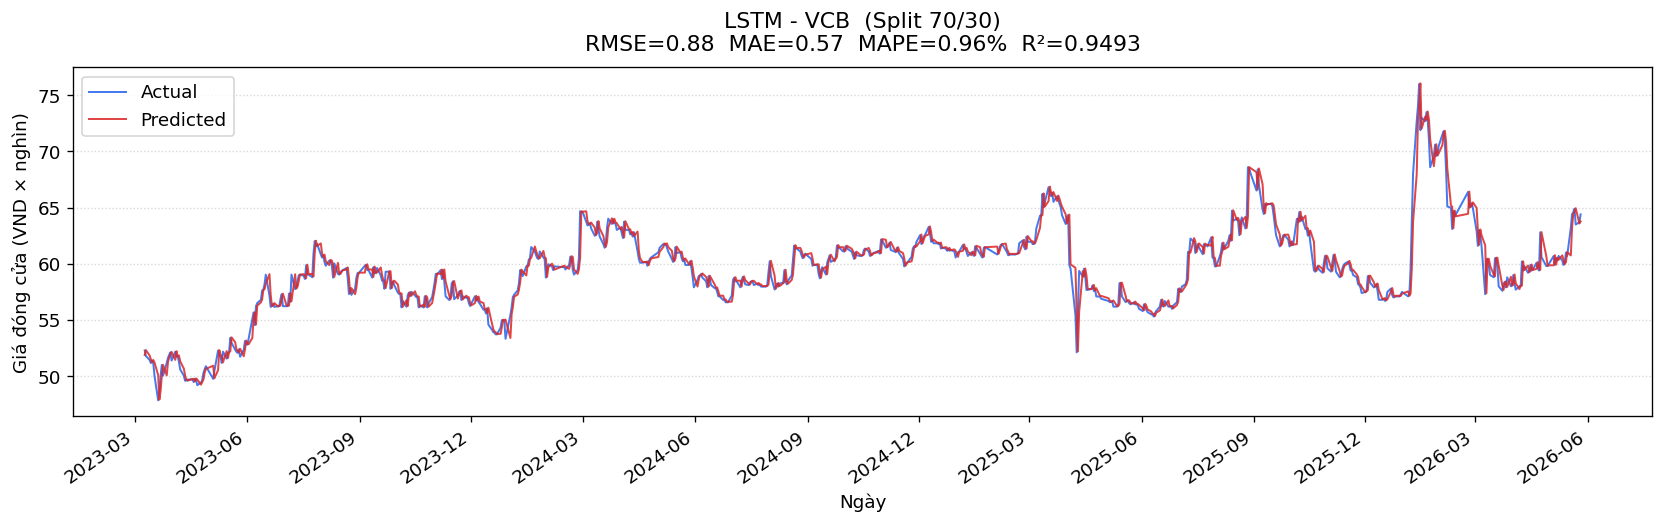


  ▶  FPT - training LSTM... (72 epochs)
     RMSE=1.62  MAE=1.14  MAPE=1.24%  R²=0.9948  DA=50.5%


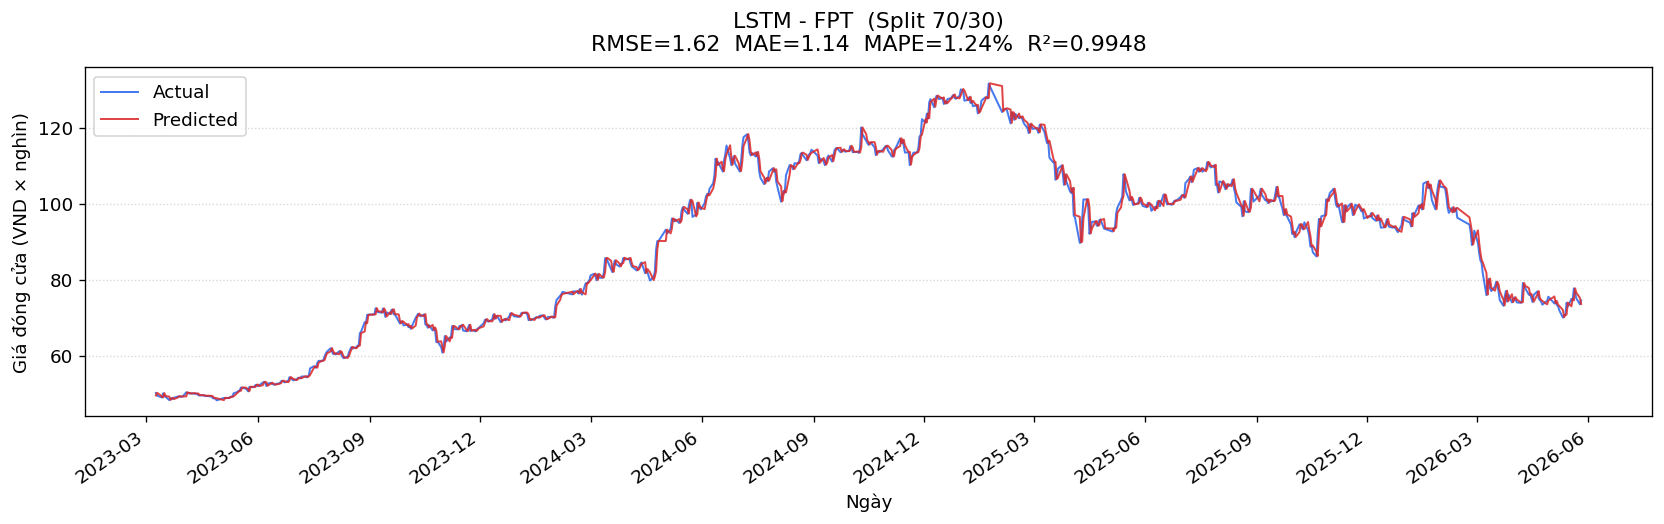


  ▶  HPG - training LSTM... (46 epochs)
     RMSE=0.35  MAE=0.25  MAPE=1.22%  R²=0.9864  DA=47.2%


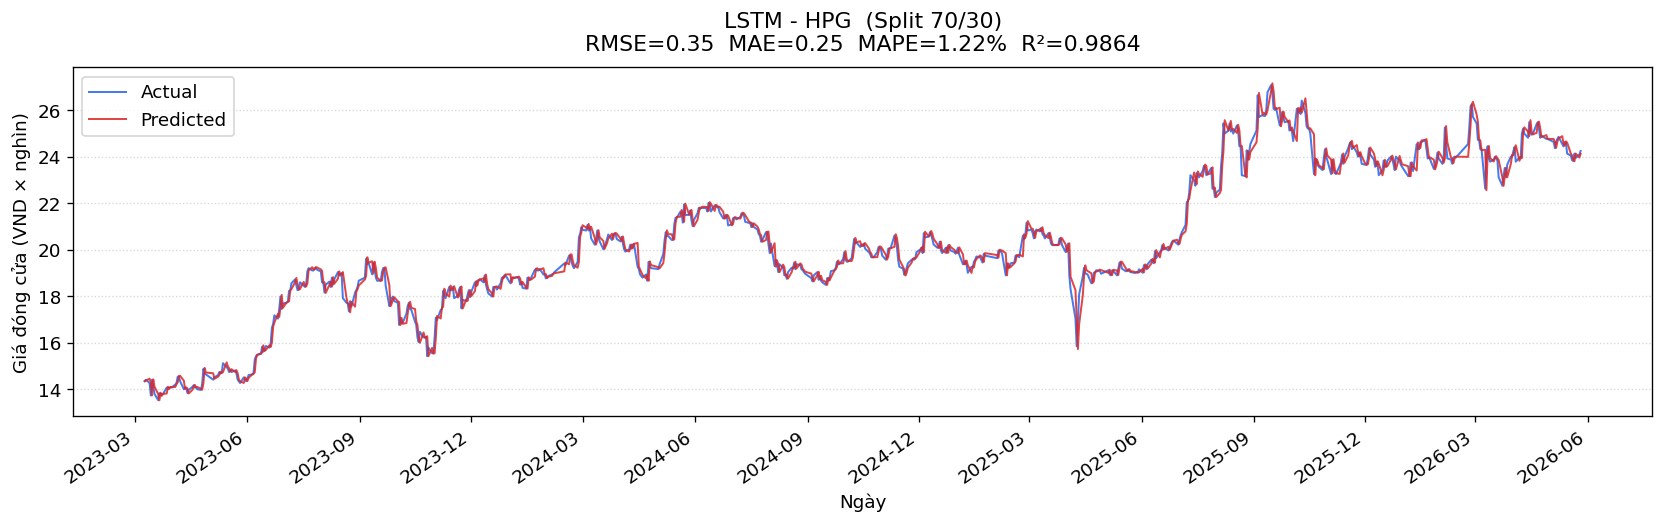


  ▶  VIC - training LSTM... (98 epochs)
     RMSE=2.56  MAE=1.20  MAPE=1.66%  R²=0.9976  DA=48.7%


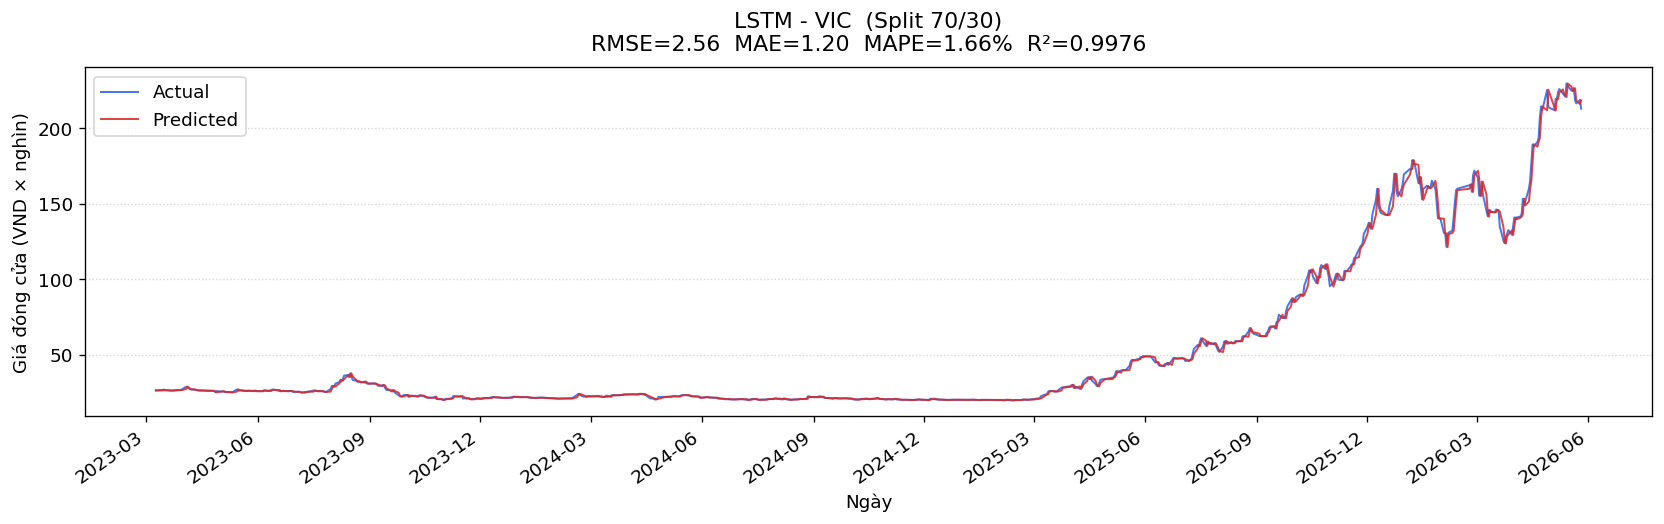


  ▶  VNM - training LSTM... (64 epochs)
     RMSE=0.89  MAE=0.60  MAPE=1.00%  R²=0.9474  DA=49.3%


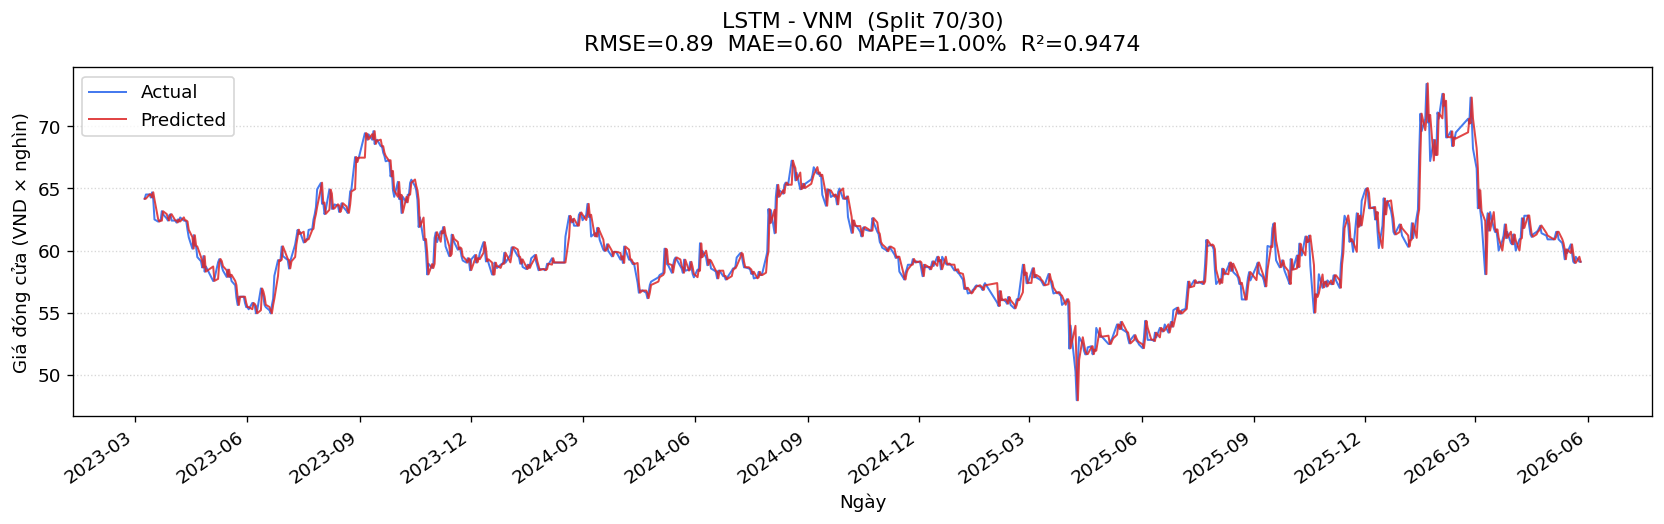


  Split: 80/20

  ▶  VCB - training LSTM... (126 epochs)
     RMSE=0.94  MAE=0.58  MAPE=0.94%  R²=0.9183  DA=48.0%


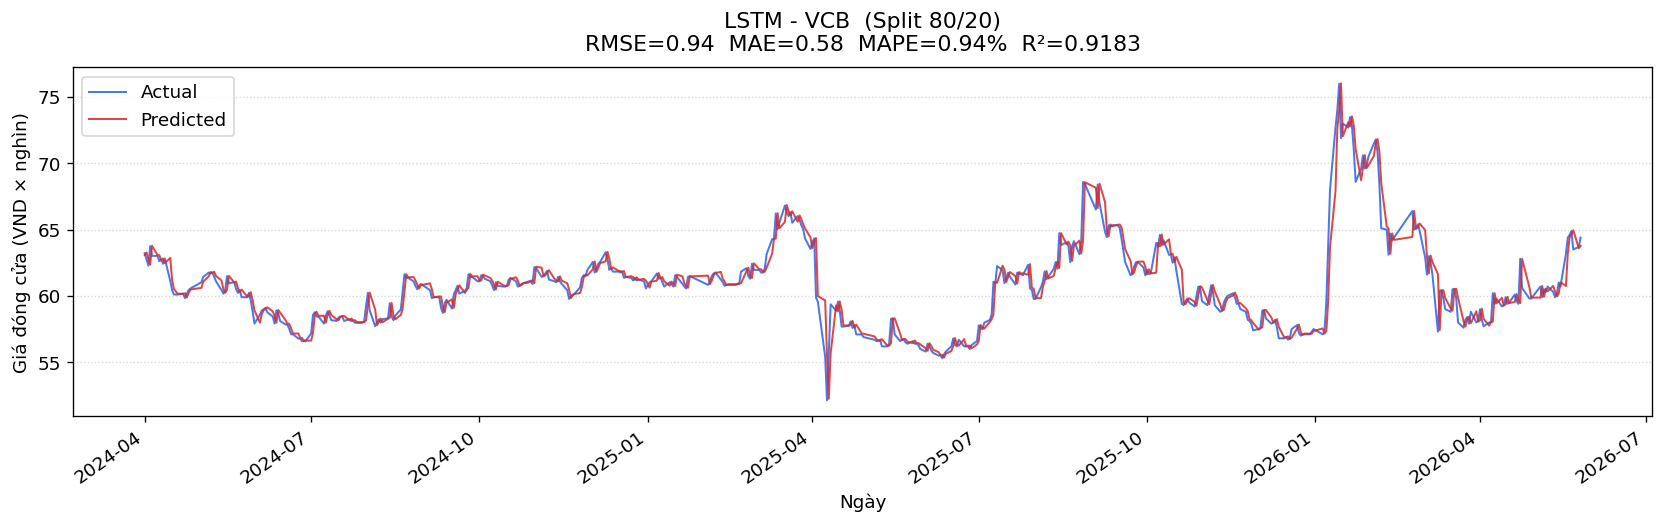


  ▶  FPT - training LSTM... (87 epochs)
     RMSE=1.89  MAE=1.41  MAPE=1.41%  R²=0.9818  DA=48.4%


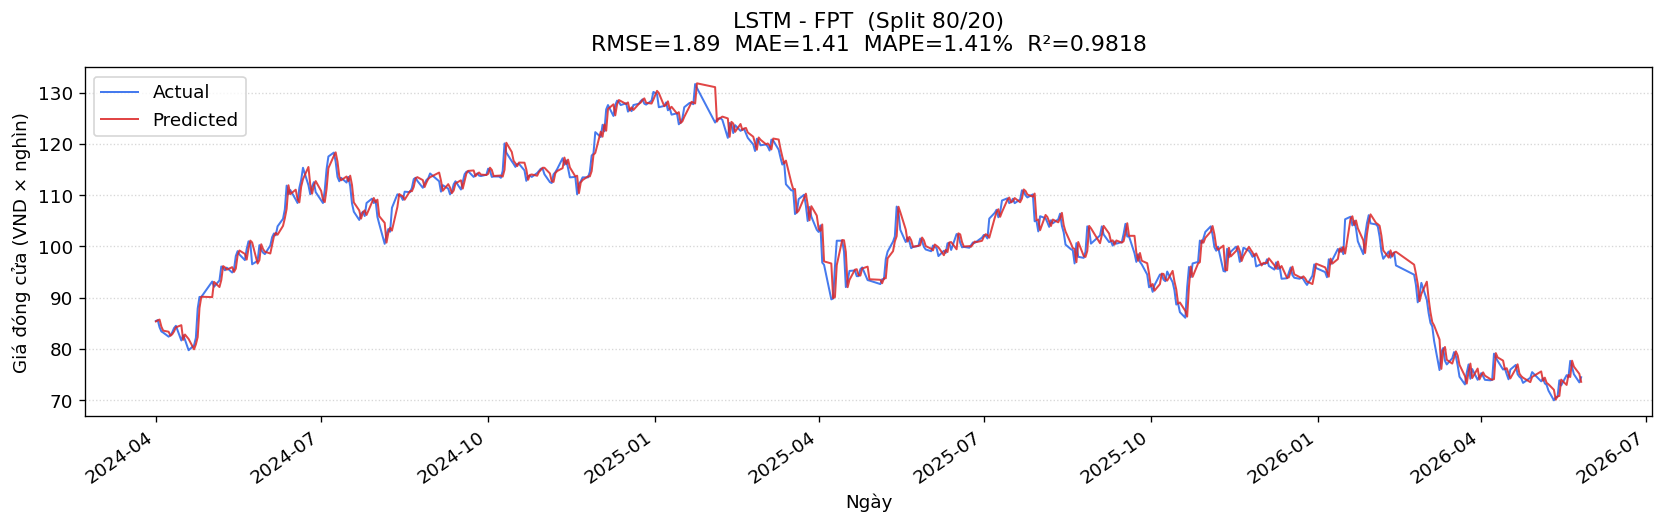


  ▶  HPG - training LSTM... (94 epochs)
     RMSE=0.37  MAE=0.26  MAPE=1.19%  R²=0.9743  DA=46.2%


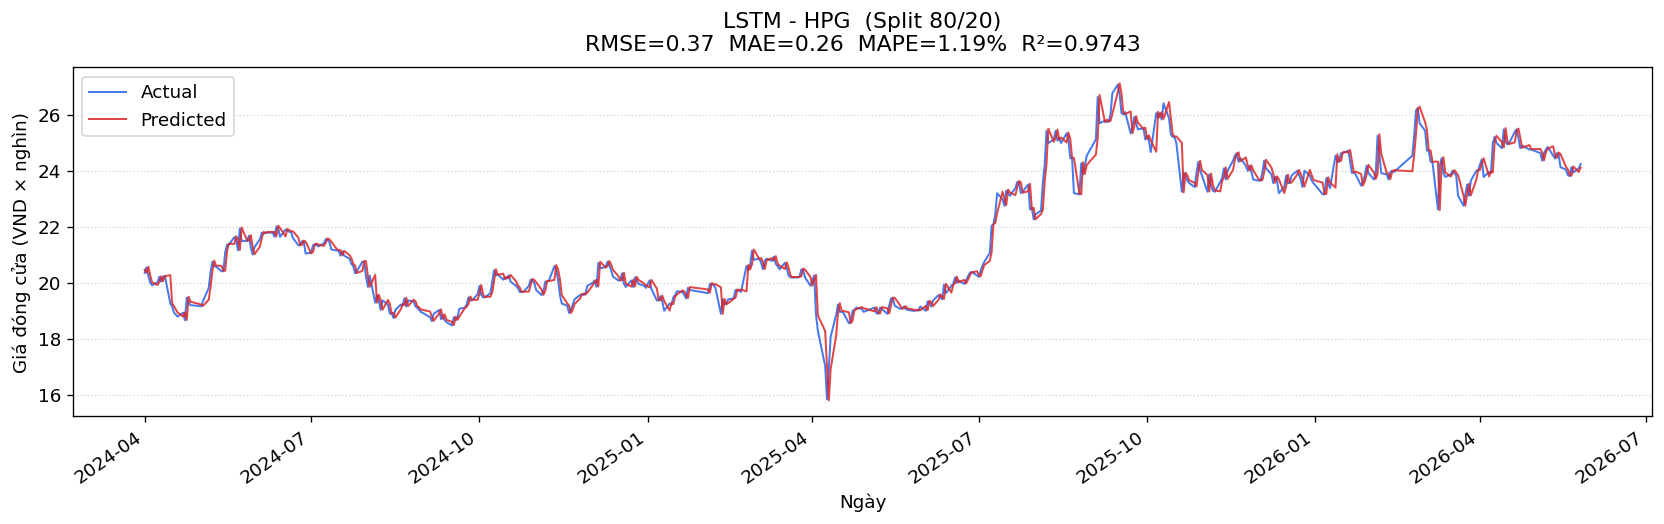


  ▶  VIC - training LSTM... (39 epochs)
     RMSE=3.08  MAE=1.63  MAPE=1.85%  R²=0.9973  DA=53.3%


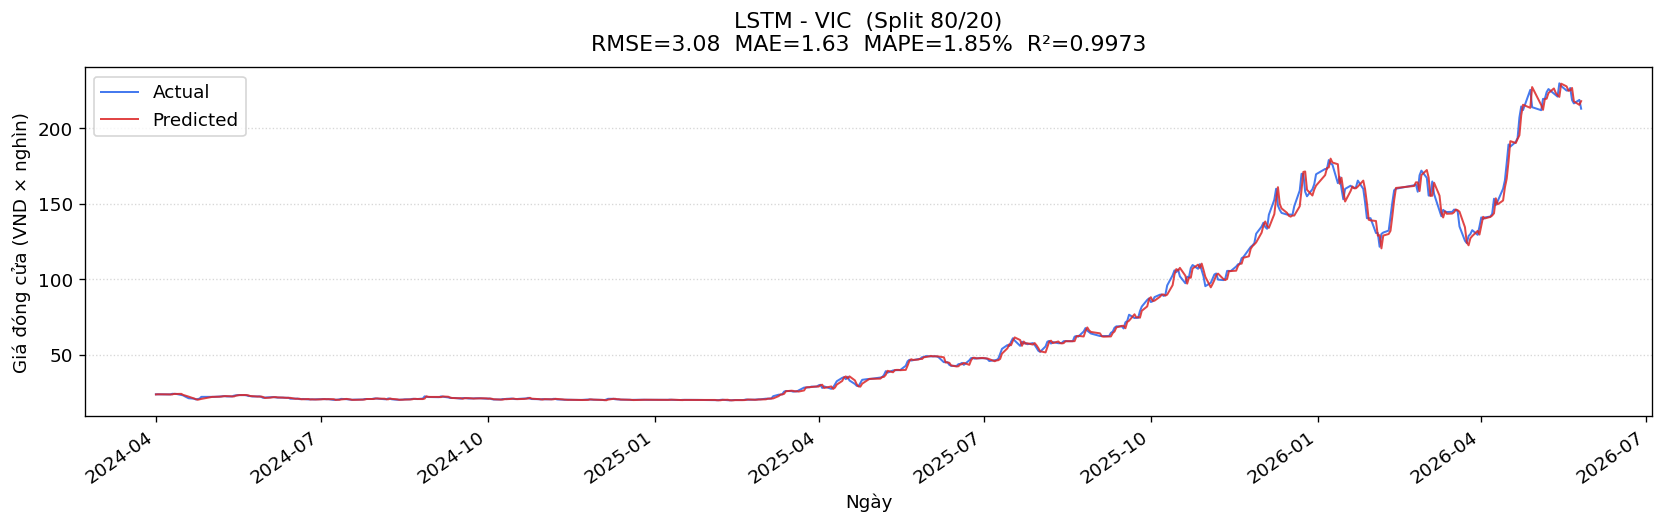


  ▶  VNM - training LSTM... (53 epochs)
     RMSE=0.97  MAE=0.65  MAPE=1.08%  R²=0.9435  DA=45.9%


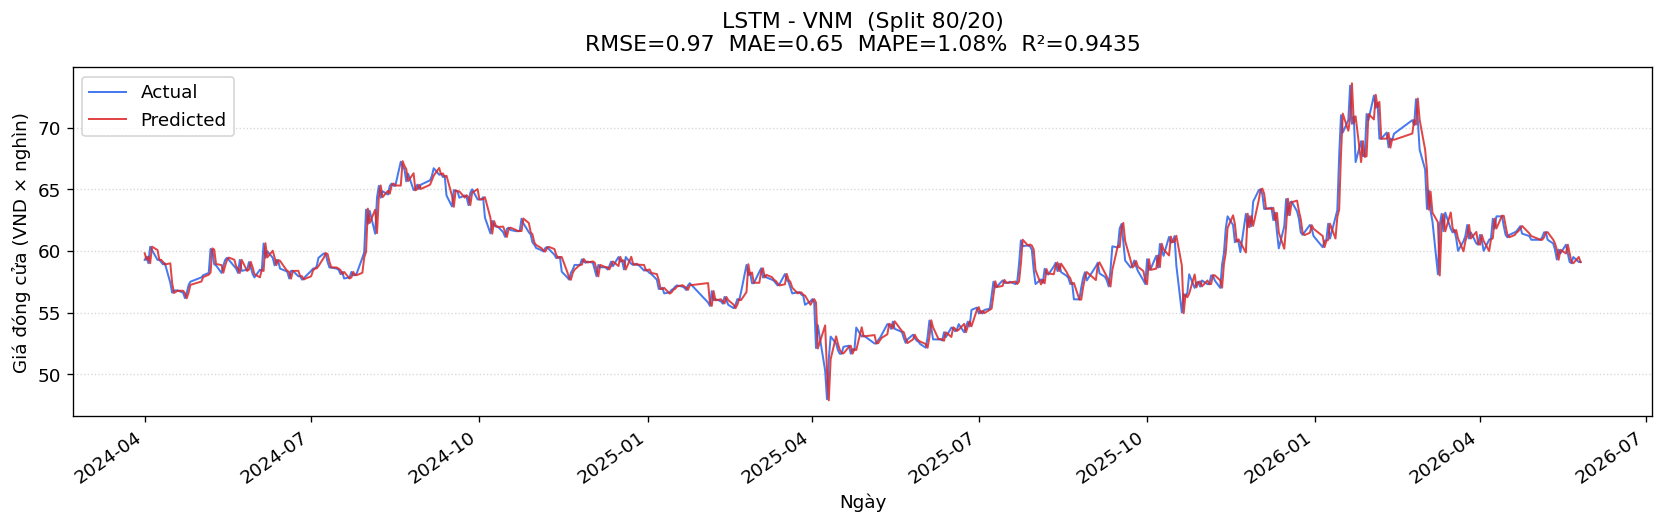

In [ ]:
MODEL_NAME_LSTM = 'LSTM'
RESULTS_DIR_LSTM = ROOT / 'results' / 'lstm'
PLOTS_DIR_LSTM   = RESULTS_DIR_LSTM / 'plots'
PLOTS_DIR_LSTM.mkdir(parents=True, exist_ok=True)

all_results_lstm = []
_pred_cache_lstm = {}   # {(ticker, split): y_pred} - cache cho Section export

for split in SPLITS:
    print(f"\n{'='*60}")
    print(f"  Split: {split.replace('_', '/')}")
    print(f"{'='*60}")

    for ticker in TICKERS:
        print(f"\n  ▶  {ticker} - training LSTM...", end=' ', flush=True)
        train_df, test_df = load_split(ticker, split)

        y_pred, hist = train_and_predict(train_df, test_df, model_type='lstm', verbose=0)
        y_true = test_df['close'].values

        # prev_close[i] = close của ngày liền trước test row i
        prev_close = np.concatenate([[train_df['close'].iloc[-1]], y_true[:-1]])

        # Metrics
        metrics = compute_metrics(y_true, y_pred, prev_close=prev_close)
        da = metrics.get('Directional Accuracy (%)', float('nan'))
        ep_stopped = len(hist.history['loss'])
        print(f"({ep_stopped} epochs)")
        print(f"     RMSE={metrics['RMSE']:,.2f}  MAE={metrics['MAE']:,.2f}  "
              f"MAPE={metrics['MAPE (%)']:.2f}%  R²={metrics['R²']:.4f}  DA={da:.1f}%")

        # Plot
        plot_predictions(
            dates=test_df['date'], y_true=y_true, y_pred=y_pred,
            ticker=ticker, split=split, model_name=MODEL_NAME_LSTM,
            metrics=metrics, plots_dir=PLOTS_DIR_LSTM,
        )

        # Collect
        all_results_lstm.append({'Ticker': ticker, 'Split': split, 'Model': MODEL_NAME_LSTM, **metrics})
        _pred_cache_lstm[(ticker, split)] = y_pred


## Section 6 - Bảng tổng hợp: LSTM

Tổng hợp metrics của 10 LSTM models (5 tickers × 2 splits) thành bảng DataFrame, in ra màn hình và lưu vào `results/lstm/lstm_results.csv`.

In [ ]:
results_lstm = build_results_table(all_results_lstm)

print(f"\n{'─'*75}")
print(f"  Kết quả: {MODEL_NAME_LSTM}")
print(f"{'─'*75}")
print(results_lstm.to_string(index=False))

out_csv_lstm = RESULTS_DIR_LSTM / 'lstm_results.csv'
results_lstm.to_csv(out_csv_lstm, index=False)
print(f"\n  Đã lưu → {out_csv_lstm}")



───────────────────────────────────────────────────────────────────────────
  Kết quả: LSTM
───────────────────────────────────────────────────────────────────────────
Ticker Split Model  RMSE  MAE  MAPE (%)     R²  Directional Accuracy (%)
   FPT 70_30  LSTM  1.62 1.14     1.243 0.9948                     50.45
   HPG 70_30  LSTM  0.35 0.25     1.217 0.9864                     47.23
   VCB 70_30  LSTM  0.88 0.57     0.956 0.9493                     48.84
   VIC 70_30  LSTM  2.56 1.20     1.663 0.9976                     48.74
   VNM 70_30  LSTM  0.89 0.60     0.998 0.9474                     49.26
   FPT 80_20  LSTM  1.89 1.41     1.410 0.9818                     48.37
   HPG 80_20  LSTM  0.37 0.26     1.189 0.9743                     46.18
   VCB 80_20  LSTM  0.94 0.58     0.945 0.9183                     48.03
   VIC 80_20  LSTM  3.08 1.63     1.854 0.9973                     53.26
   VNM 80_20  LSTM  0.97 0.65     1.075 0.9435                     45.88

  Đã lưu → /home/trieunguye

## Section 7 - Huấn luyện GRU (5 tickers × 2 splits = 10 models)

Vòng lặp train GRU, cấu trúc giống hệt Section 5. GRU thường hội tụ nhanh hơn và đạt hiệu suất tương đương hoặc tốt hơn LSTM trên bộ dữ liệu nhỏ (~1 800 sequences). Biểu đồ Actual vs Predicted cũng được **hiển thị ngay sau mỗi lần train** và lưu vào `results/gru/plots/`.


  Split: 70/30

  ▶  VCB - training GRU... (92 epochs)
     RMSE=0.88  MAE=0.57  MAPE=0.96%  R²=0.9495  DA=49.0%


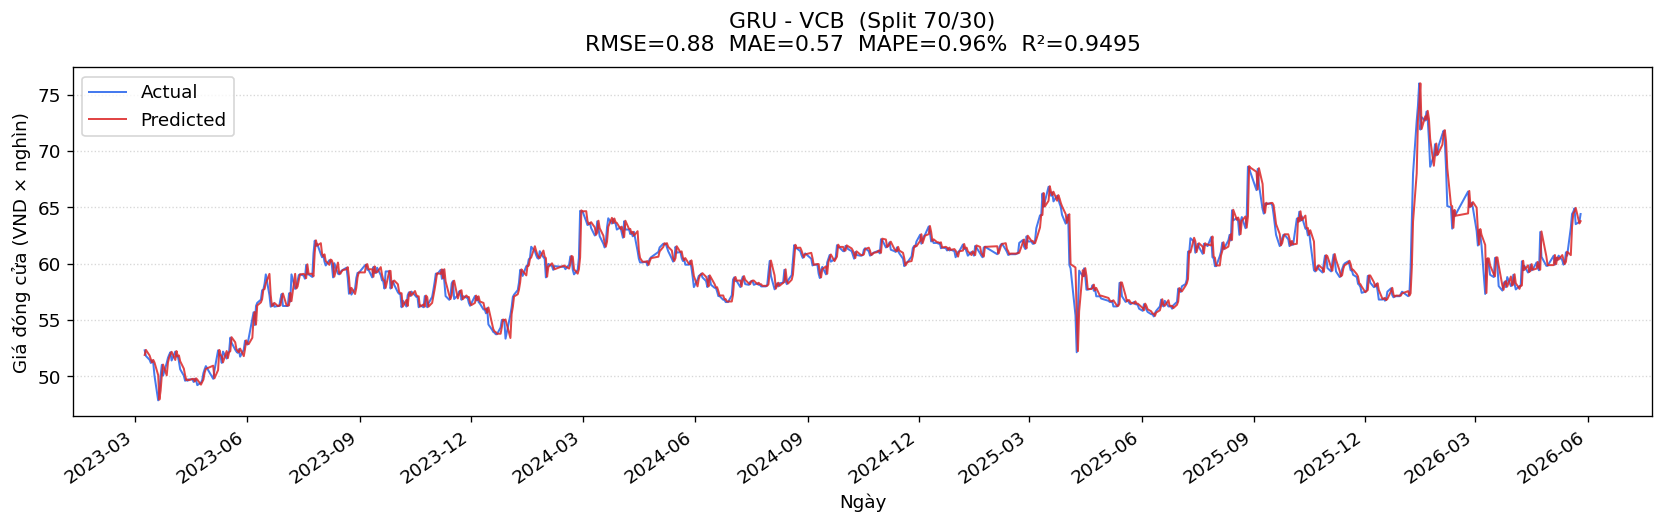


  ▶  FPT - training GRU... (67 epochs)
     RMSE=1.62  MAE=1.14  MAPE=1.24%  R²=0.9948  DA=50.3%


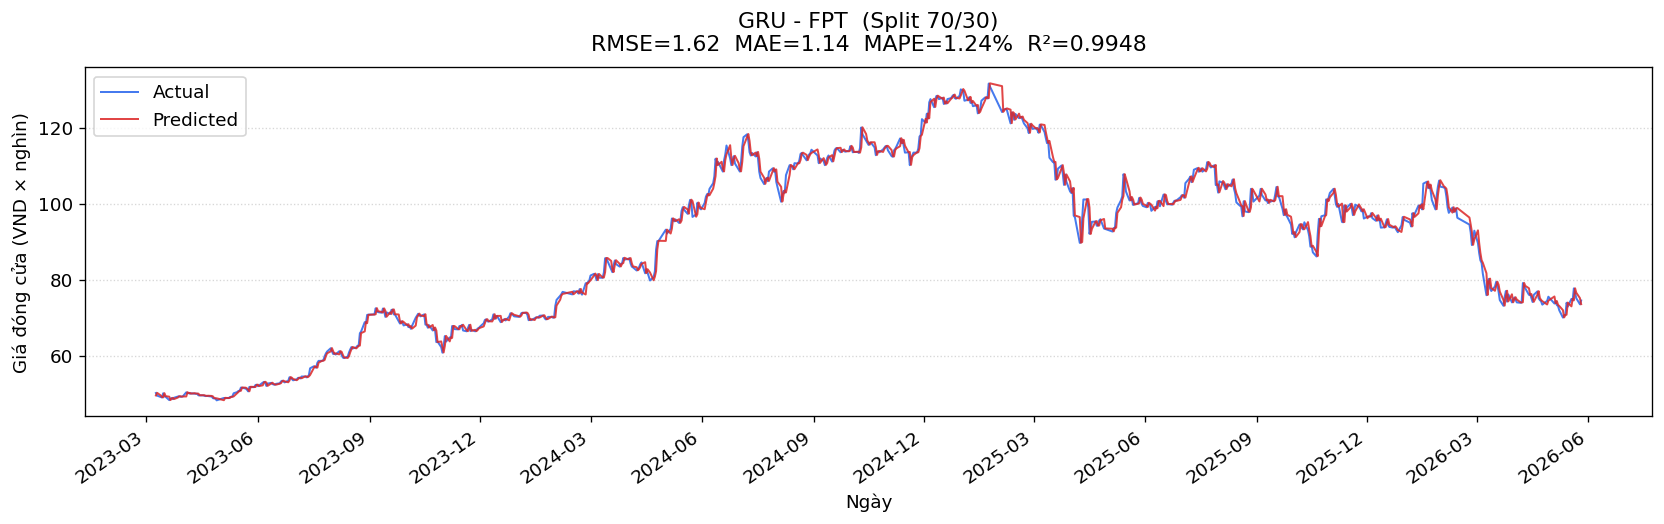


  ▶  HPG - training GRU... (43 epochs)
     RMSE=0.35  MAE=0.25  MAPE=1.21%  R²=0.9864  DA=49.9%


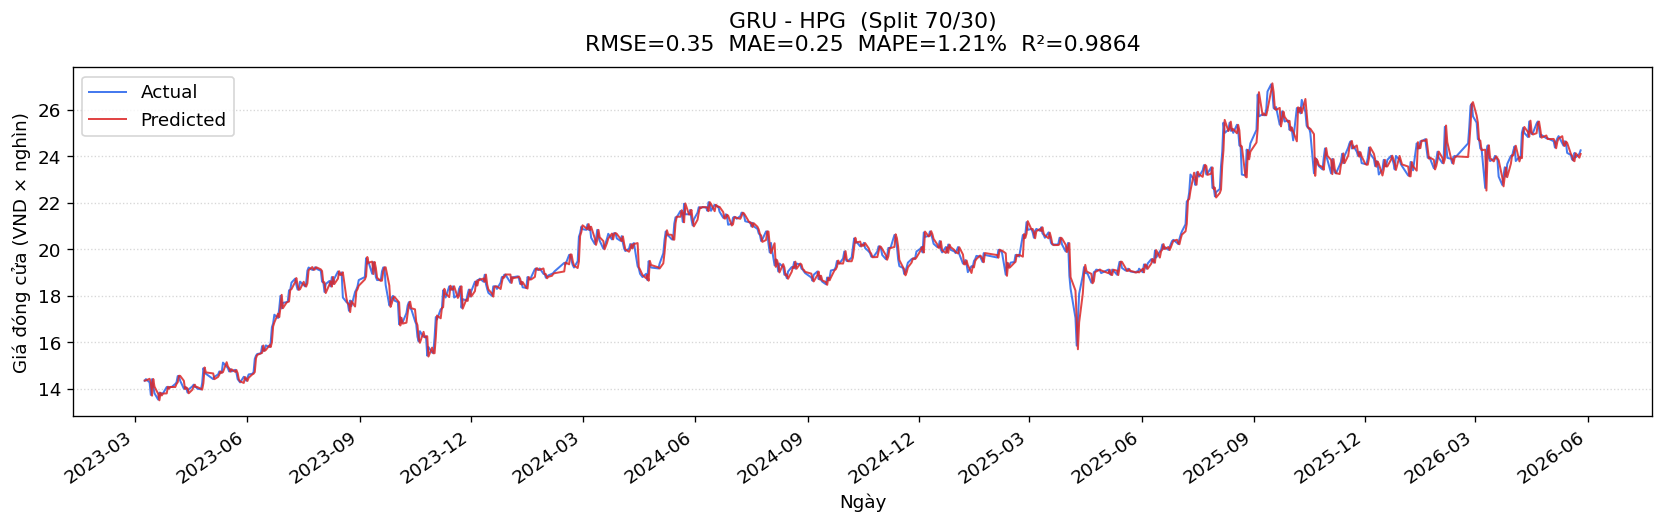


  ▶  VIC - training GRU... (90 epochs)
     RMSE=2.56  MAE=1.19  MAPE=1.66%  R²=0.9976  DA=49.9%


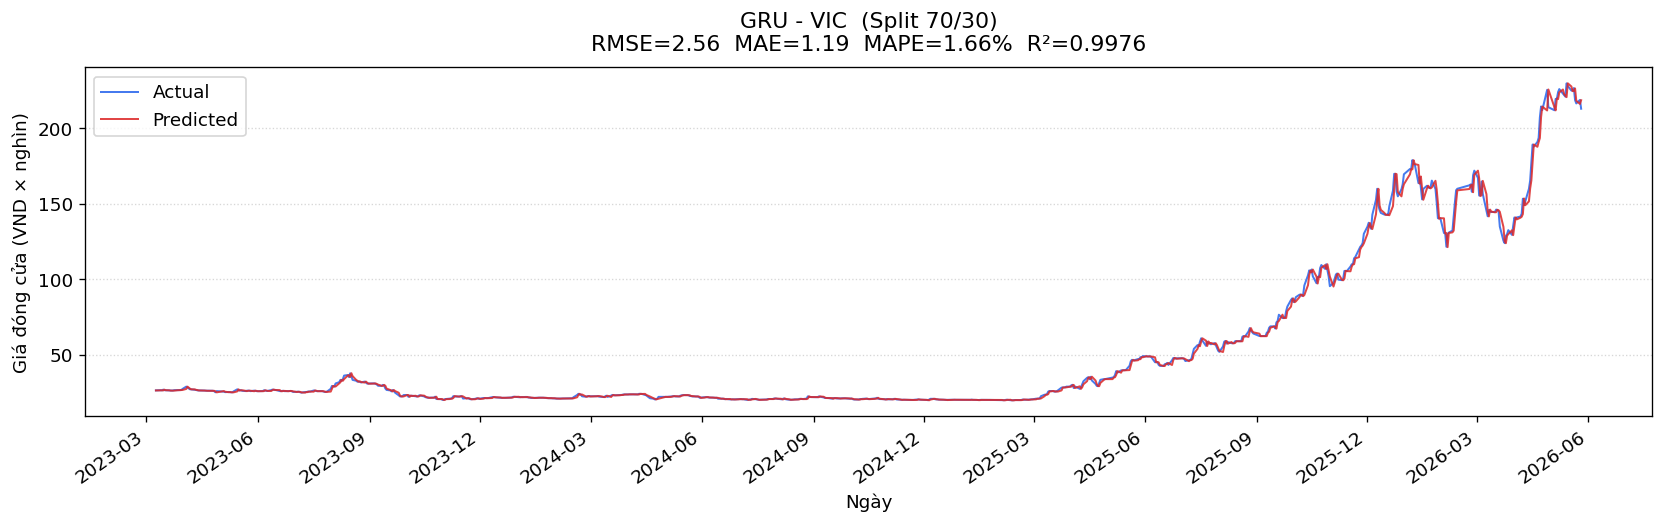


  ▶  VNM - training GRU... (76 epochs)
     RMSE=0.89  MAE=0.60  MAPE=1.00%  R²=0.9474  DA=52.0%


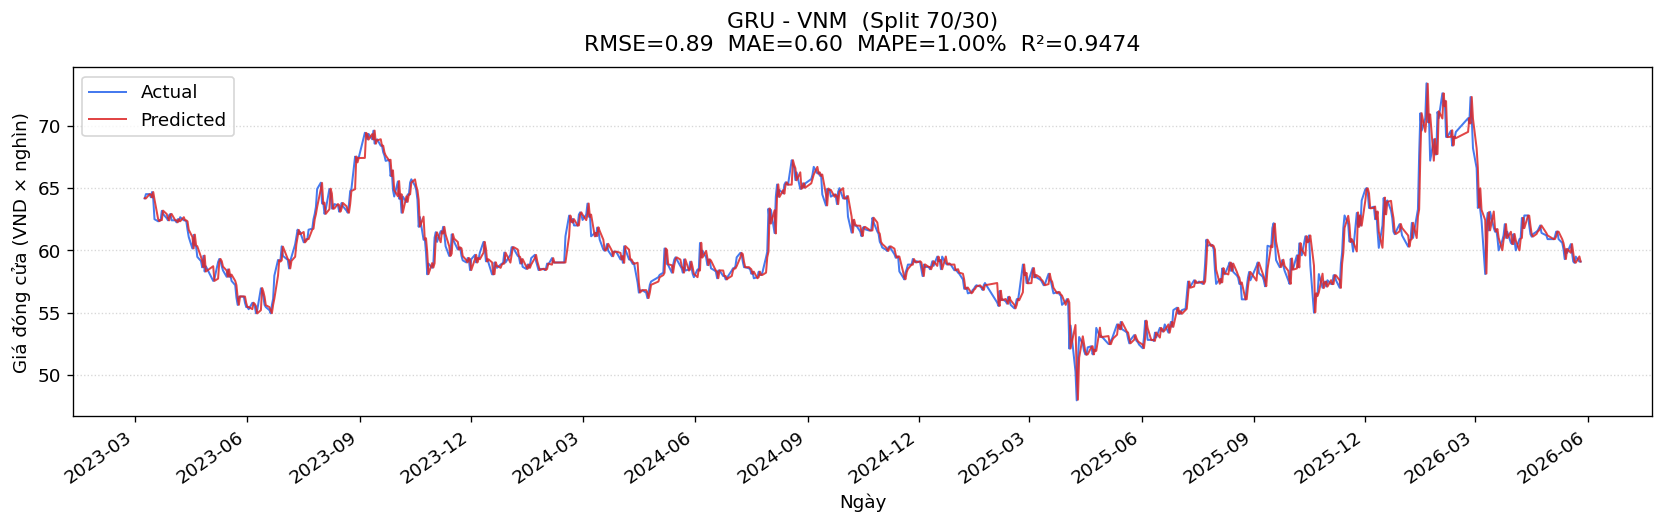


  Split: 80/20

  ▶  VCB - training GRU... (69 epochs)
     RMSE=0.94  MAE=0.58  MAPE=0.94%  R²=0.9189  DA=48.0%


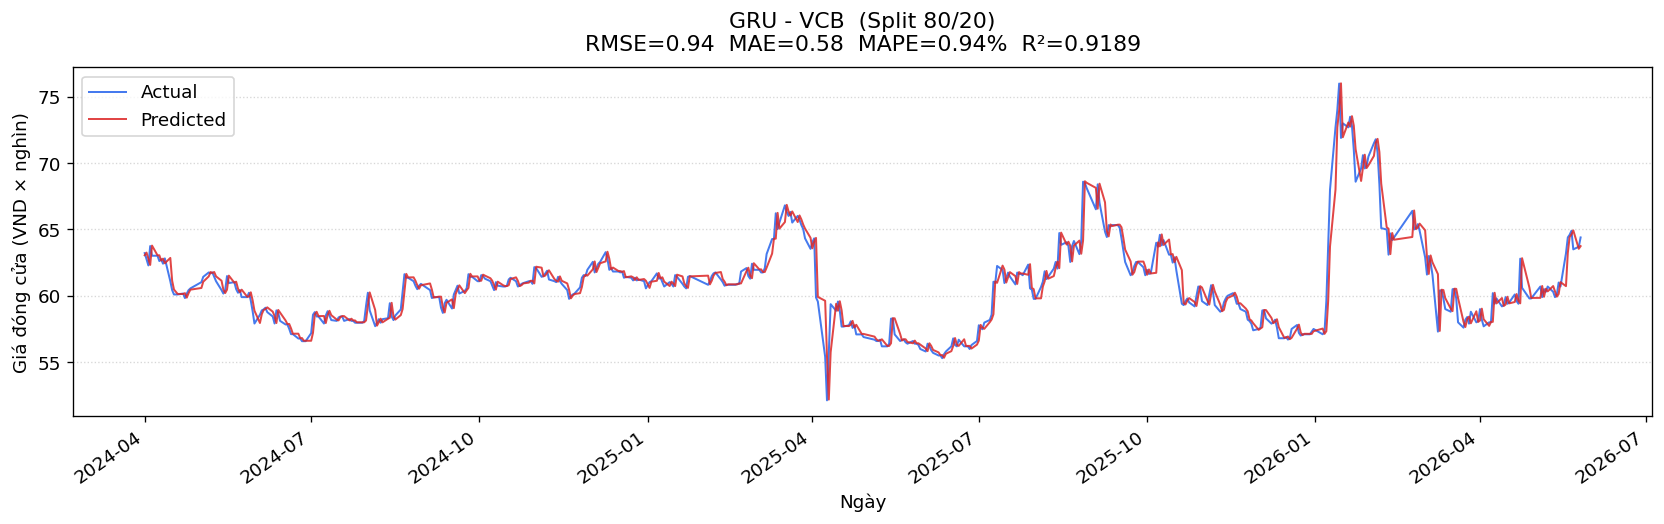


  ▶  FPT - training GRU... (84 epochs)
     RMSE=1.89  MAE=1.40  MAPE=1.41%  R²=0.9819  DA=48.6%


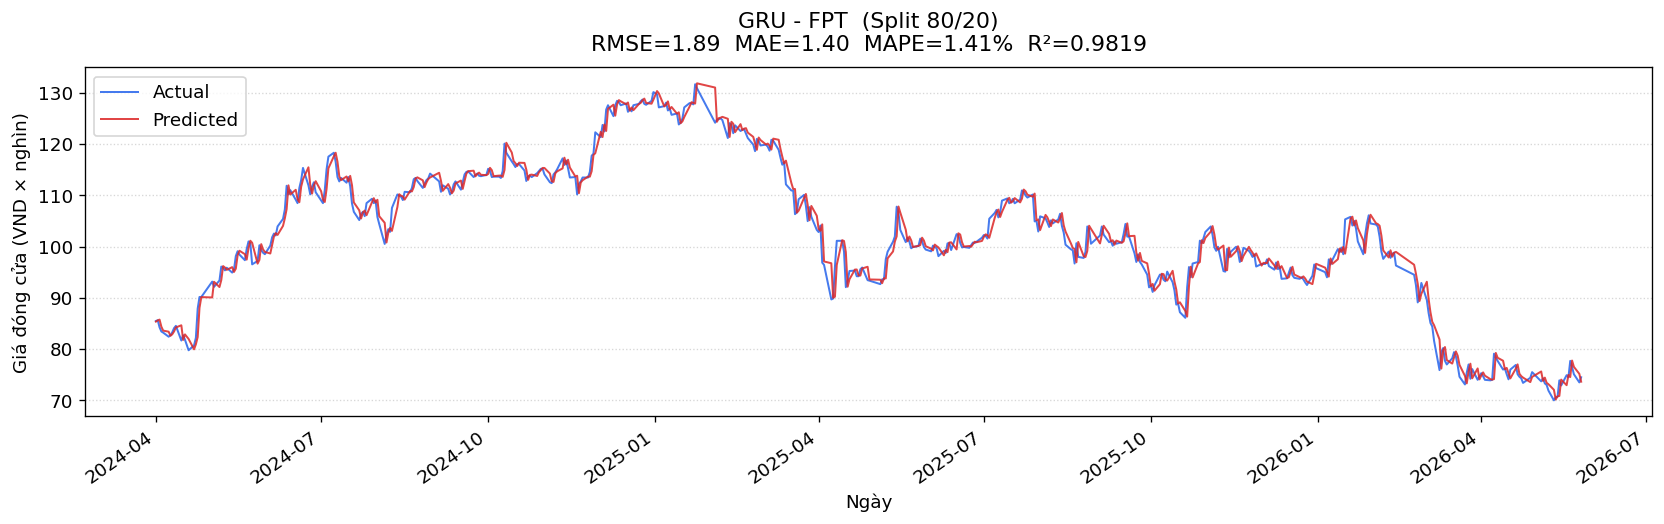


  ▶  HPG - training GRU... (100 epochs)
     RMSE=0.37  MAE=0.26  MAPE=1.19%  R²=0.9743  DA=46.4%


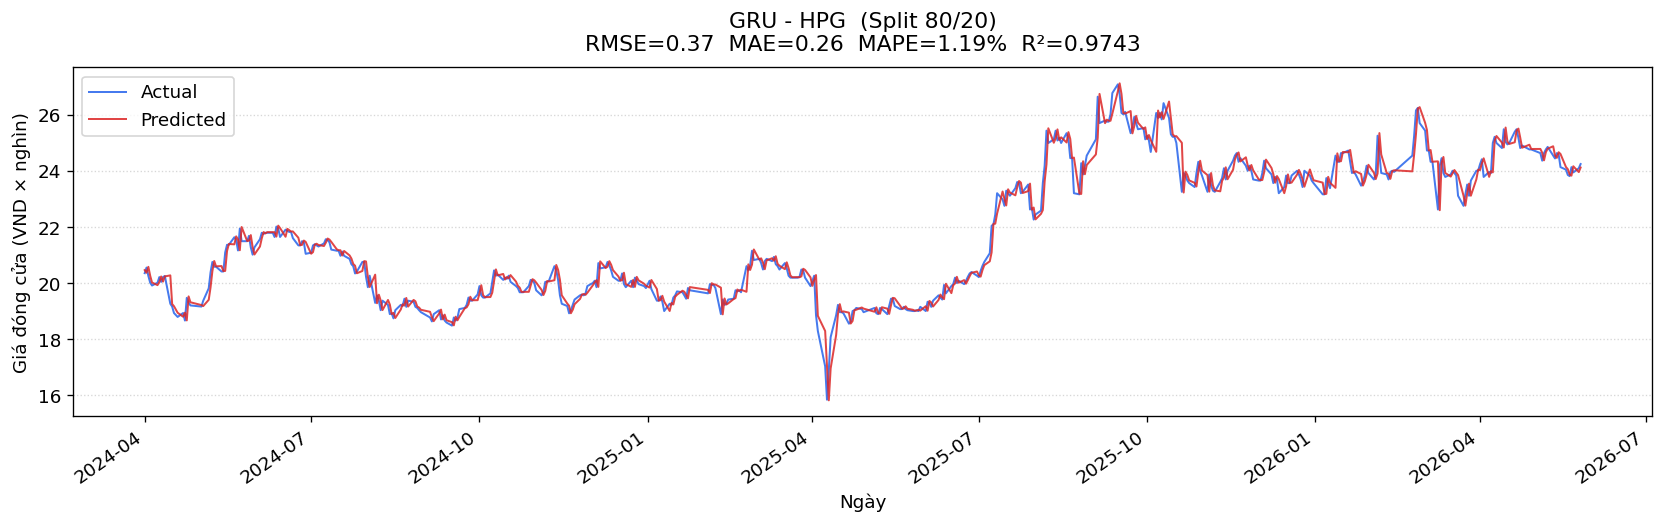


  ▶  VIC - training GRU... (37 epochs)
     RMSE=3.08  MAE=1.61  MAPE=1.83%  R²=0.9973  DA=54.7%


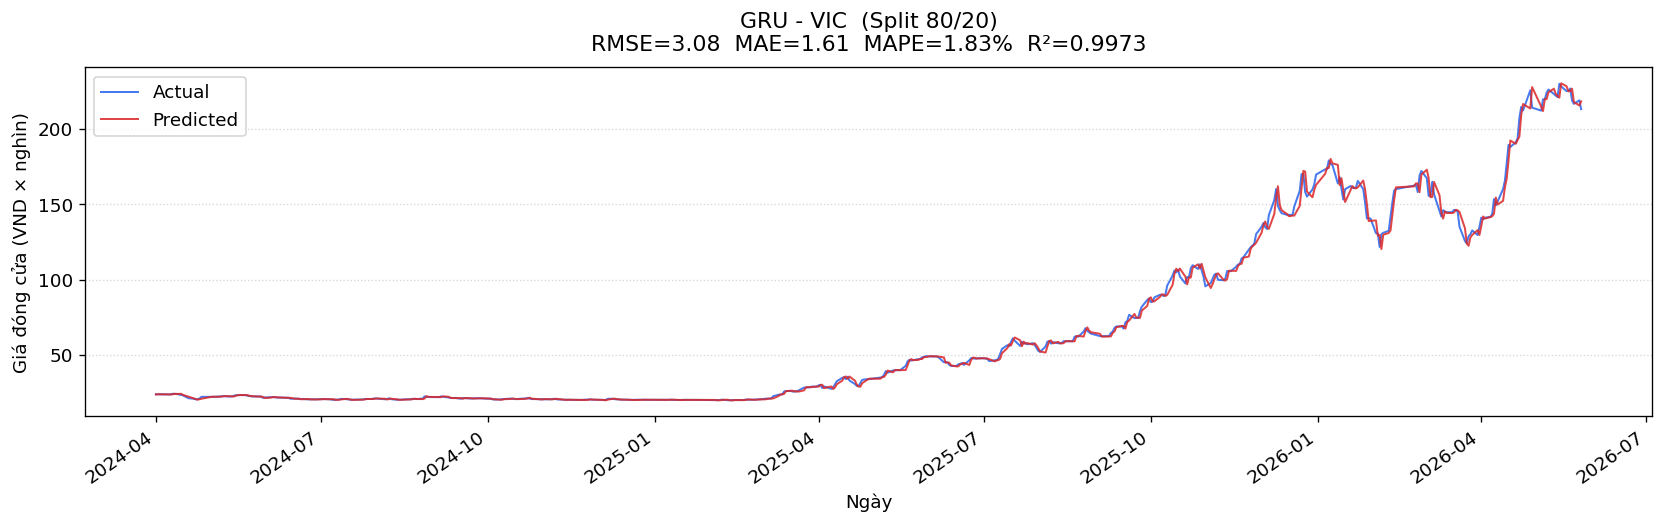


  ▶  VNM - training GRU... (51 epochs)
     RMSE=0.97  MAE=0.65  MAPE=1.08%  R²=0.9438  DA=44.1%


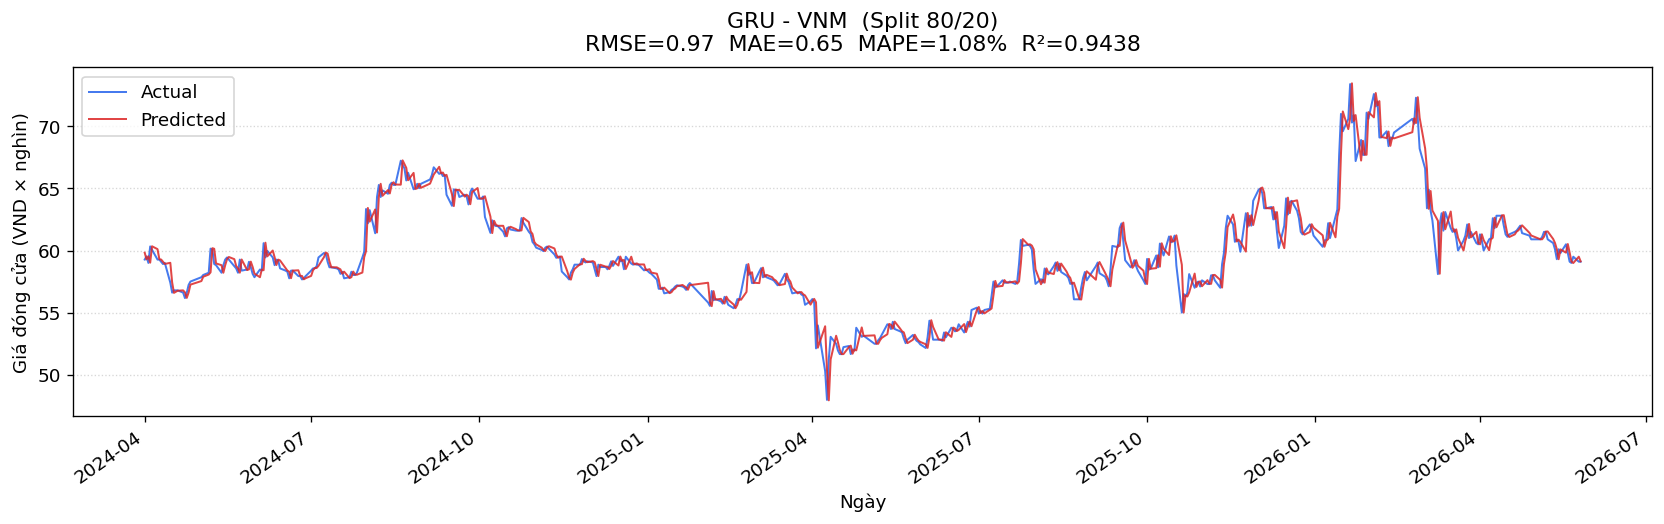

In [ ]:
MODEL_NAME_GRU = 'GRU'
RESULTS_DIR_GRU = ROOT / 'results' / 'gru'
PLOTS_DIR_GRU   = RESULTS_DIR_GRU / 'plots'
PLOTS_DIR_GRU.mkdir(parents=True, exist_ok=True)

all_results_gru = []
_pred_cache_gru = {}   # {(ticker, split): y_pred}

for split in SPLITS:
    print(f"\n{'='*60}")
    print(f"  Split: {split.replace('_', '/')}")
    print(f"{'='*60}")

    for ticker in TICKERS:
        print(f"\n  ▶  {ticker} - training GRU...", end=' ', flush=True)
        train_df, test_df = load_split(ticker, split)

        y_pred, hist = train_and_predict(train_df, test_df, model_type='gru', verbose=0)
        y_true = test_df['close'].values

        prev_close = np.concatenate([[train_df['close'].iloc[-1]], y_true[:-1]])

        # Metrics
        metrics = compute_metrics(y_true, y_pred, prev_close=prev_close)
        da = metrics.get('Directional Accuracy (%)', float('nan'))
        ep_stopped = len(hist.history['loss'])
        print(f"({ep_stopped} epochs)")
        print(f"     RMSE={metrics['RMSE']:,.2f}  MAE={metrics['MAE']:,.2f}  "
              f"MAPE={metrics['MAPE (%)']:.2f}%  R²={metrics['R²']:.4f}  DA={da:.1f}%")

        # Plot
        plot_predictions(
            dates=test_df['date'], y_true=y_true, y_pred=y_pred,
            ticker=ticker, split=split, model_name=MODEL_NAME_GRU,
            metrics=metrics, plots_dir=PLOTS_DIR_GRU,
        )

        # Collect
        all_results_gru.append({'Ticker': ticker, 'Split': split, 'Model': MODEL_NAME_GRU, **metrics})
        _pred_cache_gru[(ticker, split)] = y_pred


## Section 8 - Bảng tổng hợp: GRU

Tổng hợp metrics của 10 GRU models (5 tickers × 2 splits) thành bảng DataFrame, in ra màn hình và lưu vào `results/gru/gru_results.csv`.

In [ ]:
results_gru = build_results_table(all_results_gru)

print(f"\n{'─'*75}")
print(f"  Kết quả: {MODEL_NAME_GRU}")
print(f"{'─'*75}")
print(results_gru.to_string(index=False))

out_csv_gru = RESULTS_DIR_GRU / 'gru_results.csv'
results_gru.to_csv(out_csv_gru, index=False)
print(f"\n  Đã lưu → {out_csv_gru}")



───────────────────────────────────────────────────────────────────────────
  Kết quả: GRU
───────────────────────────────────────────────────────────────────────────
Ticker Split Model  RMSE  MAE  MAPE (%)     R²  Directional Accuracy (%)
   FPT 70_30   GRU  1.62 1.14     1.244 0.9948                     50.32
   HPG 70_30   GRU  0.35 0.25     1.207 0.9864                     49.93
   VCB 70_30   GRU  0.88 0.57     0.956 0.9495                     48.98
   VIC 70_30   GRU  2.56 1.19     1.661 0.9976                     49.86
   VNM 70_30   GRU  0.89 0.60     0.998 0.9474                     51.96
   FPT 80_20   GRU  1.89 1.40     1.408 0.9819                     48.56
   HPG 80_20   GRU  0.37 0.26     1.189 0.9743                     46.39
   VCB 80_20   GRU  0.94 0.58     0.942 0.9189                     48.03
   VIC 80_20   GRU  3.08 1.61     1.829 0.9973                     54.74
   VNM 80_20   GRU  0.97 0.65     1.075 0.9438                     44.06

  Đã lưu → /home/trieunguyen

## Section 9 - So sánh LSTM vs GRU

So sánh trực tiếp RMSE giữa LSTM và GRU theo từng ticker-split bằng bảng pivot và grouped bar chart. Chart được lưu vào `results/comparison/plots/lstm_gru_rmse_comparison.png`.

In [ ]:
combined = pd.concat([results_lstm, results_gru], ignore_index=True)

# ── Pivot bảng so sánh RMSE theo ticker × model ──
for split in SPLITS:
    subset = combined[combined['Split'] == split].copy()
    pivot  = subset.pivot(index='Ticker', columns='Model', values='RMSE')
    pivot['LSTM vs GRU'] = (pivot['LSTM'] - pivot['GRU']).round(3)
    print(f"\n  RMSE Comparison - Split {split.replace('_', '/')}")
    print(pivot.round(2).to_string())

print()

# ── Average metrics per model ──
print("\n  === Mean metrics across all tickers and splits ===")
avg = combined.groupby('Model')[['RMSE', 'MAE', 'MAPE (%)', 'R²']].mean()
print(avg.round(4).to_string())



  RMSE Comparison - Split 70/30
Model    GRU  LSTM  LSTM vs GRU
Ticker                         
FPT     1.62  1.62          0.0
HPG     0.35  0.35          0.0
VCB     0.88  0.88          0.0
VIC     2.56  2.56          0.0
VNM     0.89  0.89          0.0

  RMSE Comparison - Split 80/20
Model    GRU  LSTM  LSTM vs GRU
Ticker                         
FPT     1.89  1.89          0.0
HPG     0.37  0.37          0.0
VCB     0.94  0.94          0.0
VIC     3.08  3.08          0.0
VNM     0.97  0.97          0.0


  === Mean metrics across all tickers and splits ===
        RMSE    MAE  MAPE (%)      R²
Model                                
GRU    1.355  0.825    1.2509  0.9692
LSTM   1.355  0.829    1.2550  0.9691


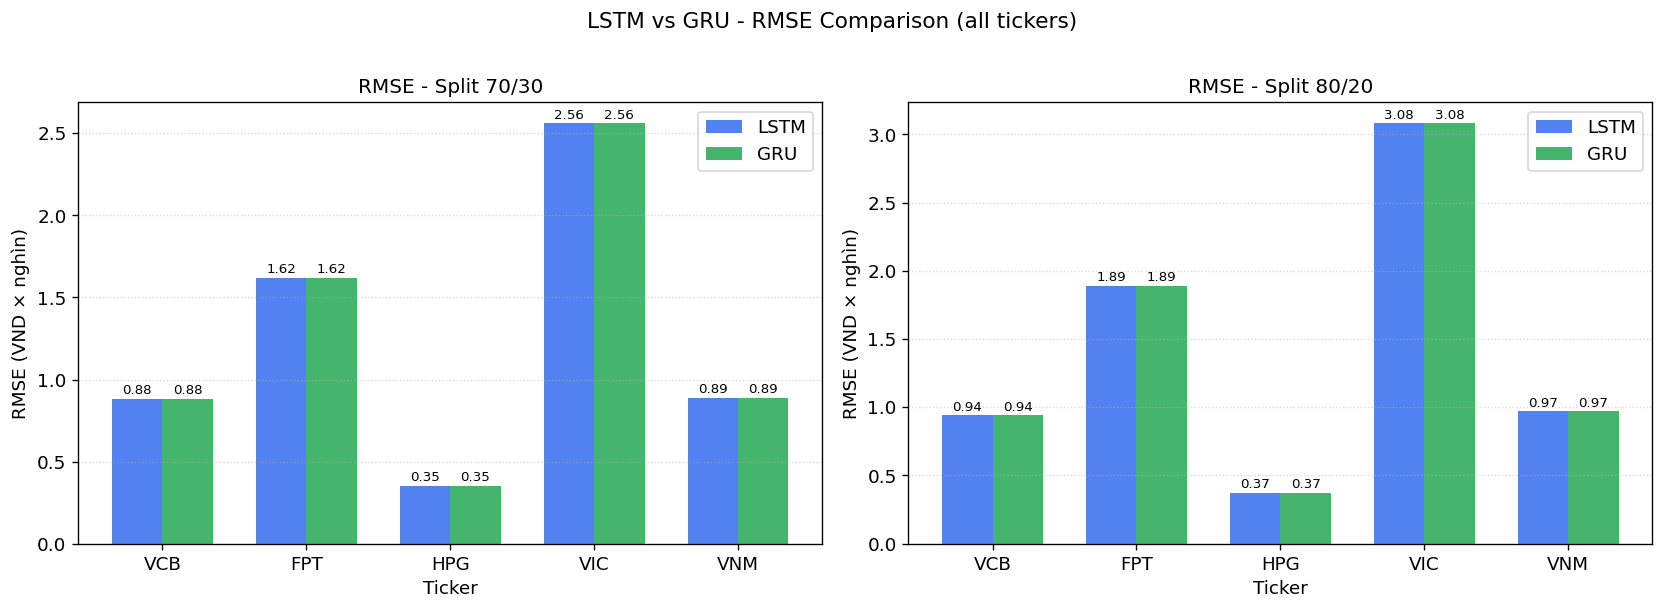

  Đã lưu → /home/trieunguyen/work/eagle-a/vault/ml-and-applications/stock-time-series/results/comparison/plots/lstm_gru_rmse_comparison.png


In [ ]:
# Biểu đồ so sánh RMSE: LSTM vs GRU trên cả 5 ticker × 2 splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

x = np.arange(len(TICKERS))
width = 0.35

for ax, split in zip(axes, SPLITS):
    sub = combined[combined['Split'] == split]
    lstm_rmse = sub[sub['Model'] == 'LSTM'].set_index('Ticker').loc[TICKERS, 'RMSE'].values
    gru_rmse  = sub[sub['Model'] == 'GRU' ].set_index('Ticker').loc[TICKERS, 'RMSE'].values

    bars1 = ax.bar(x - width/2, lstm_rmse, width, label='LSTM', color='#2563EB', alpha=0.8)
    bars2 = ax.bar(x + width/2, gru_rmse,  width, label='GRU',  color='#16A34A', alpha=0.8)

    ax.set_title(f'RMSE - Split {split.replace("_", "/")}', fontsize=12)
    ax.set_xlabel('Ticker')
    ax.set_ylabel('RMSE (VND × nghìn)')
    ax.set_xticks(x)
    ax.set_xticklabels(TICKERS)
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Annotate bars
    for bar in bars1:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
    for bar in bars2:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.suptitle('LSTM vs GRU - RMSE Comparison (all tickers)', fontsize=13, y=1.01)
plt.tight_layout()

# Lưu comparison plot vào cả hai thư mục
compare_plot = ROOT / 'results' / 'comparison' / 'plots' / 'lstm_gru_rmse_comparison.png'
compare_plot.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(compare_plot, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Đã lưu → {compare_plot}')


## Section 10 - Export sang GitHub Pages Dashboard

Export predictions và metrics của cả LSTM và GRU vào `docs/data/` để dashboard nhóm có thể hiển thị kết quả từ cả 3 thành viên. Cập nhật `docs/data/manifest.json` để dashboard nhận diện model mới. Dùng cache từ vòng lặp trên - **không re-train**.

In [ ]:
import shutil

DOCS_DATA = ROOT / 'docs' / 'data'
DOCS_DATA.mkdir(parents=True, exist_ok=True)

for model_slug, cache, model_display in [
    ('lstm', _pred_cache_lstm, MODEL_NAME_LSTM),
    ('gru',  _pred_cache_gru,  MODEL_NAME_GRU),
]:
    # ── 1. Export predictions ──
    pred_rows = []
    for split in SPLITS:
        for ticker in TICKERS:
            _, test_df = load_split(ticker, split)
            y_true = test_df['close'].values
            y_pred = cache[(ticker, split)]
            for idx_row, row in enumerate(test_df.itertuples()):
                pred_rows.append({
                    'date':      str(row.date.date()),
                    'actual':    round(float(y_true[idx_row]), 4),
                    'predicted': round(float(y_pred[idx_row]), 4),
                    'ticker':    ticker,
                    'split':     split,
                    'model':     model_display,
                })

    pred_df = pd.DataFrame(pred_rows)
    pred_path = DOCS_DATA / f'{model_slug}_predictions.csv'
    pred_df.to_csv(pred_path, index=False)

    # ── 2. Export metrics ──
    metrics_src = RESULTS_DIR_LSTM if model_slug == 'lstm' else RESULTS_DIR_GRU
    shutil.copy(metrics_src / f'{model_slug}_results.csv',
                DOCS_DATA / f'{model_slug}_metrics.csv')

    print(f'  [{model_display}] predictions → {pred_path}')

# ── 3. Update manifest (follow template pattern) ──
manifest_path = DOCS_DATA / 'manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
else:
    manifest = {'models': []}

for model_slug, model_display in [('lstm', MODEL_NAME_LSTM), ('gru', MODEL_NAME_GRU)]:
    entry = {
        'name':        model_display,
        'predictions': f'data/{model_slug}_predictions.csv',
        'metrics':     f'data/{model_slug}_metrics.csv',
    }
    # Remove existing entry for this model (overwrite stale), then append
    manifest['models'] = [m for m in manifest['models'] if m['name'] != model_display]
    manifest['models'].append(entry)

manifest['last_updated'] = pd.Timestamp.now().strftime('%Y-%m-%d')
manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print(f'  manifest → {manifest_path}  ({len(manifest["models"])} model(s))')
print('\nExport hoàn tất!')


NameError: name 'ROOT' is not defined